# 50 — Sign Reversal and Semantic Inversion Matrix

**Purpose:** Produce the strongest possible mechanistic evidence for why cross-dataset
VPN detection fails. This notebook is the keystone diagnostic artifact for the thesis.

**Output directory:** `artifacts/thesis_finalization/nb50_sign_reversal_matrix/`

### What changes relative to earlier notebooks?
- NB44 established the existence of sign reversals. This notebook deepens the analysis
  with effect sizes, Mann–Whitney tests, single-feature AUC, and connects reversals
  directly to model failure in LODO evaluation.

## 0. Setup

In [1]:
import sys, json, warnings, os
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.15)
np.random.seed(42)

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.clean_pipeline.feature_families import SAFE_CORE_PLUS_TEMPORAL
CLEAN = ROOT / "artifacts" / "clean_pipeline"
NB44  = ROOT / "artifacts" / "thesis_class_conditional_audit_notebook"
OUT   = ROOT / "artifacts" / "thesis_finalization" / "nb50_sign_reversal_matrix"
OUT.mkdir(parents=True, exist_ok=True)
FEAT_COLS = list(SAFE_CORE_PLUS_TEMPORAL)
SEED = 42; EPS = 1e-9; TIMESTAMP = datetime.now().isoformat()

def save_json(obj, n):
    p = OUT / n; open(p,"w").write(json.dumps(obj,indent=2,default=str)); print(f"  ✓ {p}")
def save_md(t, n):
    (OUT / n).write_text(t, encoding="utf-8"); print(f"  ✓ {OUT/n}")
def save_csv(d, n):
    p = OUT / n; (d if isinstance(d,pd.DataFrame) else pd.DataFrame(d)).to_csv(p); print(f"  ✓ {p}")
def save_fig(f, n, dpi=200):
    p = OUT / n; f.savefig(p, dpi=dpi, bbox_inches="tight", facecolor="white"); plt.close(f); print(f"  ✓ {p}")

df = pd.read_parquet(CLEAN / "features.parquet")
DATASETS = sorted(df["dataset"].unique())
print(f"Loaded {len(df):,} flows, {len(DATASETS)} datasets, {len(FEAT_COLS)} features")

Loaded 72,612 flows, 3 datasets, 21 features


---
## C8. Per-Feature Class-Conditional Direction Analysis

For each feature and dataset, compute:
- Standardized mean difference (VPN − nonVPN)
- Single-feature AUC
- Cliff's delta / Mann–Whitney effect sign
- Sign consistency across datasets

In [2]:
def cliffs_delta(x, y):
    """Compute Cliff's delta effect size."""
    nx, ny = len(x), len(y)
    if nx == 0 or ny == 0:
        return 0.0
    # Use Mann-Whitney U to compute
    u, _ = mannwhitneyu(x, y, alternative='two-sided')
    delta = (2 * u) / (nx * ny) - 1
    return float(delta)

rows = []
for feat in FEAT_COLS:
    for ds in DATASETS:
        ds_data = df[df["dataset"] == ds]
        vpn = ds_data[ds_data["label"] == 1][feat].dropna().values
        nonvpn = ds_data[ds_data["label"] == 0][feat].dropna().values
        
        row = {"feature": feat, "dataset": ds, "n_vpn": len(vpn), "n_nonvpn": len(nonvpn)}
        
        if len(vpn) > 0 and len(nonvpn) > 0:
            # Standardized mean difference
            diff = vpn.mean() - nonvpn.mean()
            pooled_std = np.sqrt(
                ((len(vpn)-1)*vpn.std()**2 + (len(nonvpn)-1)*nonvpn.std()**2) /
                max(len(vpn)+len(nonvpn)-2, 1)
            )
            row["smd"] = diff / max(pooled_std, EPS)
            row["sign"] = "+" if row["smd"] > 0 else "-"
            row["abs_smd"] = abs(row["smd"])
            
            # Single-feature AUC
            y_true = np.concatenate([np.ones(len(vpn)), np.zeros(len(nonvpn))])
            scores = np.concatenate([vpn, nonvpn])
            try:
                auc = roc_auc_score(y_true, scores)
                row["single_feat_auc"] = auc
            except:
                row["single_feat_auc"] = np.nan
            
            # Cliff's delta
            row["cliffs_delta"] = cliffs_delta(vpn, nonvpn)
            row["mw_sign"] = "+" if row["cliffs_delta"] > 0 else "-"
            
            # Mann-Whitney p-value
            try:
                _, p_val = mannwhitneyu(vpn, nonvpn, alternative="two-sided")
                row["mw_pvalue"] = p_val
            except:
                row["mw_pvalue"] = np.nan
        else:
            row.update({"smd": np.nan, "sign": "?", "abs_smd": np.nan,
                       "single_feat_auc": np.nan, "cliffs_delta": np.nan,
                       "mw_sign": "?", "mw_pvalue": np.nan})
        rows.append(row)

analysis_df = pd.DataFrame(rows)
print("=== Class-conditional analysis (sample) ===")
print(analysis_df.head(15).to_string(index=False))

=== Class-conditional analysis (sample) ===
       feature dataset  n_vpn  n_nonvpn       smd sign  abs_smd  single_feat_auc  cliffs_delta mw_sign     mw_pvalue
 total_packets    iscx   2943      8858  0.421018    + 0.421018         0.592312      0.184624       +  1.851716e-51
 total_packets  usbvpn   8456     44248  1.608532    + 1.608532         0.764841      0.529682       +  0.000000e+00
 total_packets    vnat    374      7733  0.329563    + 0.329563         0.215240     -0.569521       -  6.135602e-88
   total_bytes    iscx   2943      8858  0.112954    + 0.112954         0.547922      0.095844       +  5.900503e-15
   total_bytes  usbvpn   8456     44248  1.350691    + 1.350691         0.767097      0.534194       +  0.000000e+00
   total_bytes    vnat    374      7733  0.018131    + 0.018131         0.206029     -0.587942       -  3.345644e-85
  mean_pkt_len    iscx   2943      8858 -0.016057    - 0.016057         0.463193     -0.073614       -  2.000965e-09
  mean_pkt_len  usbv

---
## C8b. Class-Conditional Jensen–Shannon Divergence

For each feature and dataset pair, compute JSD separately for:
- **VPN flows only**: JSD(dataset_A_VPN, dataset_B_VPN)
- **nonVPN flows only**: JSD(dataset_A_nonVPN, dataset_B_nonVPN)

This reveals whether the distribution shift is **class-specific**.

In [3]:
from scipy.spatial.distance import jensenshannon
from itertools import combinations

def histogram_jsd(a, b, bins=50):
    """Compute JSD between two 1D arrays using histogram-based estimation."""
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    a = a[np.isfinite(a)]; b = b[np.isfinite(b)]
    if len(a) < 5 or len(b) < 5: return np.nan
    lo = min(a.min(), b.min()); hi = max(a.max(), b.max())
    if hi == lo: return 0.0
    edges = np.linspace(lo, hi, bins + 1)
    ha, _ = np.histogram(a, bins=edges, density=True)
    hb, _ = np.histogram(b, bins=edges, density=True)
    ha = ha + EPS; hb = hb + EPS
    ha /= ha.sum(); hb /= hb.sum()
    return float(jensenshannon(ha, hb))

jsd_rows = []
ds_pairs = list(combinations(DATASETS, 2))
for feat in FEAT_COLS:
    for ds_a, ds_b in ds_pairs:
        for label, label_name in [(1, 'VPN'), (0, 'nonVPN')]:
            vals_a = df[(df['dataset']==ds_a) & (df['label']==label)][feat].dropna().values
            vals_b = df[(df['dataset']==ds_b) & (df['label']==label)][feat].dropna().values
            jsd_rows.append({'feature': feat, 'dataset_a': ds_a, 'dataset_b': ds_b,
                'class': label_name, 'label': label, 'n_a': len(vals_a), 'n_b': len(vals_b),
                'jsd': histogram_jsd(vals_a, vals_b)})
        vals_a = df[df['dataset']==ds_a][feat].dropna().values
        vals_b = df[df['dataset']==ds_b][feat].dropna().values
        jsd_rows.append({'feature': feat, 'dataset_a': ds_a, 'dataset_b': ds_b,
            'class': 'ALL', 'label': -1, 'n_a': len(vals_a), 'n_b': len(vals_b),
            'jsd': histogram_jsd(vals_a, vals_b)})

jsd_df = pd.DataFrame(jsd_rows)
save_csv(jsd_df, 'class_conditional_jsd.csv')

jsd_summary = jsd_df.groupby('class')['jsd'].agg(['mean','std','median']).reset_index()
print('=== Class-Conditional JSD Summary ===')
print(jsd_summary.to_string(index=False))

vpn_mean = jsd_df[jsd_df['class']=='VPN']['jsd'].mean()
nonvpn_mean = jsd_df[jsd_df['class']=='nonVPN']['jsd'].mean()
all_mean = jsd_df[jsd_df['class']=='ALL']['jsd'].mean()
print(f'\nMean JSD -- VPN: {vpn_mean:.4f}, nonVPN: {nonvpn_mean:.4f}, ALL: {all_mean:.4f}')
if vpn_mean > nonvpn_mean:
    print('-> VPN traffic diverges MORE between datasets than nonVPN traffic.')
else:
    print('-> nonVPN traffic diverges MORE between datasets than VPN traffic.')

fig, axes = plt.subplots(1, 2, figsize=(16, 12))
for ax_i, (cls_name, ax) in enumerate(zip(['VPN', 'nonVPN'], axes)):
    sub = jsd_df[jsd_df['class']==cls_name]
    sub_pivot = sub.pivot_table(index='feature', columns=['dataset_a','dataset_b'],
                                 values='jsd', aggfunc='first')
    sub_pivot = sub_pivot.reindex(FEAT_COLS)
    sub_pivot.columns = [f'{a} vs {b}' for a, b in sub_pivot.columns]
    sns.heatmap(sub_pivot, annot=True, fmt='.3f', cmap='YlOrRd',
                ax=ax, linewidths=0.5, cbar_kws={'label': 'JSD'})
    ax.set_title(f'{cls_name} Traffic: JSD Across Dataset Pairs')
    ax.set_ylabel('Feature')
plt.tight_layout()
save_fig(fig, 'class_conditional_jsd_heatmap.png')

fig2, ax2 = plt.subplots(figsize=(14, 8))
feat_jsd = jsd_df[jsd_df['class'].isin(['VPN','nonVPN'])].groupby(['feature','class'])['jsd'].mean().unstack()
feat_jsd = feat_jsd.reindex(FEAT_COLS)
feat_jsd.plot(kind='bar', ax=ax2, width=0.7)
ax2.set_ylabel('Mean JSD across dataset pairs')
ax2.set_title('Class-Conditional JSD: VPN vs nonVPN per Feature')
ax2.legend(title='Class')
ax2.tick_params(axis='x', rotation=45)
plt.tight_layout()
save_fig(fig2, 'class_conditional_jsd_bar.png')
print('Class-conditional JSD experiment complete.')


  ✓ C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_finalization\nb50_sign_reversal_matrix\class_conditional_jsd.csv
=== Class-Conditional JSD Summary ===
 class     mean      std   median
   ALL 0.274811 0.151058 0.250071
   VPN 0.488465 0.194225 0.545388
nonVPN 0.288155 0.161004 0.264709

Mean JSD -- VPN: 0.4885, nonVPN: 0.2882, ALL: 0.2748
-> VPN traffic diverges MORE between datasets than nonVPN traffic.
  ✓ C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_finalization\nb50_sign_reversal_matrix\class_conditional_jsd_heatmap.png
  ✓ C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_finalization\nb50_sign_reversal_matrix\class_conditional_jsd_bar.png
Class-conditional JSD experiment complete.


---
## C9. Main Sign-Reversal Table

In [4]:
# Create pivot tables from analysis_df
smd_pivot = analysis_df.pivot_table(index="feature", columns="dataset", values="smd")
sign_pivot = np.sign(smd_pivot)
auc_pivot = analysis_df.pivot_table(index="feature", columns="dataset", values="single_feat_auc")
delta_pivot = analysis_df.pivot_table(index="feature", columns="dataset", values="cliffs_delta")

# Build combined table with THREE reversal definitions
matrix_rows = []
for feat in FEAT_COLS:
    row = {"feature": feat}
    signs_smd = []
    signs_auc = []
    signs_delta = []
    for ds in DATASETS:
        sign_val = sign_pivot.loc[feat, ds] if feat in sign_pivot.index and ds in sign_pivot.columns else "?"
        smd_val = smd_pivot.loc[feat, ds] if feat in smd_pivot.index and ds in smd_pivot.columns else np.nan
        auc_val = auc_pivot.loc[feat, ds] if feat in auc_pivot.index and ds in auc_pivot.columns else np.nan
        delta_val = delta_pivot.loc[feat, ds] if feat in delta_pivot.index and ds in delta_pivot.columns else np.nan
        row[f"{ds}_sign"] = sign_val
        row[f"{ds}_smd"] = smd_val
        row[f"{ds}_auc"] = auc_val
        row[f"{ds}_delta"] = delta_val
        if sign_val != "?":
            signs_smd.append(sign_val)
        if not np.isnan(auc_val):
            signs_auc.append("+" if auc_val > 0.5 else "-")
        if not np.isnan(delta_val):
            signs_delta.append("+" if delta_val > 0 else "-")
    
    row["reversal_by_smd"] = len(set(signs_smd)) > 1 if signs_smd else False
    row["reversal_by_auc"] = len(set(signs_auc)) > 1 if signs_auc else False
    row["reversal_by_delta"] = len(set(signs_delta)) > 1 if signs_delta else False
    row["triple_consensus_reversal"] = (row["reversal_by_smd"] and
                                         row["reversal_by_auc"] and
                                         row["reversal_by_delta"])
    row["any_definition_reversal"] = (row["reversal_by_smd"] or
                                       row["reversal_by_auc"] or
                                       row["reversal_by_delta"])
    row["n_definitions_agree"] = sum([row["reversal_by_smd"],
                                       row["reversal_by_auc"],
                                       row["reversal_by_delta"]])
    row["consistent"] = not row["reversal_by_smd"]
    row["max_abs_effect"] = float(analysis_df[analysis_df["feature"]==feat]["abs_smd"].max())
    if row["triple_consensus_reversal"]:
        row["reversal_category"] = "CONSENSUS_REVERSAL"
    elif row["any_definition_reversal"]:
        row["reversal_category"] = "PARTIAL_REVERSAL"
    else:
        row["reversal_category"] = "CONSISTENT"
    matrix_rows.append(row)

matrix_df = pd.DataFrame(matrix_rows)

print("=== Sign Reversal Matrix ===")
display_cols = ["feature"] + [f"{ds}_sign" for ds in DATASETS] + ["reversal_by_smd", "reversal_by_auc", "reversal_by_delta", "triple_consensus_reversal", "reversal_category"]
print(matrix_df[display_cols].to_string(index=False))

n_smd = matrix_df["reversal_by_smd"].sum()
n_auc = matrix_df["reversal_by_auc"].sum()
n_delta = matrix_df["reversal_by_delta"].sum()
n_consensus = matrix_df["triple_consensus_reversal"].sum()
n_any = matrix_df["any_definition_reversal"].sum()
n_consistent = len(matrix_df) - n_any
n_reversing = int(n_smd)

print(f"\n--- Reversal by definition ---")
print(f"  SMD sign:       {n_smd}/{len(matrix_df)}")
print(f"  AUC direction:  {n_auc}/{len(matrix_df)}")
print(f"  Cliff's delta:  {n_delta}/{len(matrix_df)}")
print(f"  Triple consensus (all 3): {n_consensus}/{len(matrix_df)}")
print(f"  Any definition (union):   {n_any}/{len(matrix_df)}")

save_csv(matrix_df, "sign_reversal_matrix.csv")

consensus_features = matrix_df[["feature", "reversal_by_smd", "reversal_by_auc",
    "reversal_by_delta", "triple_consensus_reversal", "any_definition_reversal",
    "n_definitions_agree", "reversal_category", "max_abs_effect"]]
save_csv(consensus_features, "consensus_reversal_features.csv")


=== Sign Reversal Matrix ===
       feature  iscx_sign  usbvpn_sign  vnat_sign  reversal_by_smd  reversal_by_auc  reversal_by_delta  triple_consensus_reversal  reversal_category
 total_packets        1.0          1.0        1.0            False             True               True                      False   PARTIAL_REVERSAL
   total_bytes        1.0          1.0        1.0            False             True               True                      False   PARTIAL_REVERSAL
  mean_pkt_len       -1.0          1.0       -1.0             True             True               True                       True CONSENSUS_REVERSAL
   std_pkt_len        1.0          1.0       -1.0             True             True               True                       True CONSENSUS_REVERSAL
median_pkt_len       -1.0          1.0       -1.0             True             True               True                       True CONSENSUS_REVERSAL
   p25_pkt_len       -1.0          1.0        1.0             True           

---
## C10. Visualizations

In [5]:
# 1. Sign heatmap (SMD values with color indicating direction)
fig, ax = plt.subplots(figsize=(10, 12))
heatmap_data = smd_pivot.reindex(FEAT_COLS)
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=ax, linewidths=0.5, cbar_kws={"label": "SMD (VPN − nonVPN)"})
ax.set_title("Feature Direction Heatmap: SMD (VPN − nonVPN) per Dataset", fontsize=13)
ax.set_ylabel("Feature"); ax.set_xlabel("Dataset")
plt.tight_layout()
save_fig(fig, "sign_reversal_heatmap.png")

# 2. Effect-size heatmap (absolute SMD)
fig2, ax2 = plt.subplots(figsize=(10, 12))
abs_data = smd_pivot.reindex(FEAT_COLS).abs()
sns.heatmap(abs_data, annot=True, fmt=".2f", cmap="YlOrRd",
            ax=ax2, linewidths=0.5, cbar_kws={"label": "|SMD|"})
ax2.set_title("Absolute Effect Size Heatmap", fontsize=13)
plt.tight_layout()
save_fig(fig2, "effect_size_heatmap.png")

# 3. Reversal-strength ranking bar chart
sorted_feats = matrix_df.sort_values("max_abs_effect", ascending=True)
fig3, ax3 = plt.subplots(figsize=(10, 12))
colors = ["#4CAF50" if c else "#F44336" for c in sorted_feats["consistent"]]
ax3.barh(sorted_feats["feature"], sorted_feats["max_abs_effect"], color=colors)
ax3.set_xlabel("Max |SMD| across datasets")
ax3.set_title("Feature Effect Strength\n(Green=consistent, Red=reversing)")
ax3.axvline(x=0.2, color="gray", linestyle="--", alpha=0.5, label="small effect")
ax3.axvline(x=0.5, color="gray", linestyle="-.", alpha=0.5, label="medium effect")
ax3.legend()
plt.tight_layout()
save_fig(fig3, "reversal_strength_ranking.png")

# 4. Single-feature AUC comparison
fig4, ax4 = plt.subplots(figsize=(12, 8))
auc_long = analysis_df[["feature", "dataset", "single_feat_auc"]].dropna()
if len(auc_long) > 0:
    auc_piv = auc_long.pivot(index="feature", columns="dataset", values="single_feat_auc")
    auc_piv = auc_piv.reindex(FEAT_COLS)
    auc_piv.plot(kind="bar", ax=ax4, width=0.8)
    ax4.axhline(y=0.5, color="red", linestyle="--", label="random")
    ax4.set_ylabel("Single-feature AUC")
    ax4.set_title("Per-Feature VPN Detection AUC by Dataset")
    ax4.legend(title="Dataset")
    ax4.tick_params(axis='x', rotation=45)
plt.tight_layout()
save_fig(fig4, "single_feature_auc_comparison.png")
print("All visualizations saved.")

  ✓ C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_finalization\nb50_sign_reversal_matrix\sign_reversal_heatmap.png
  ✓ C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_finalization\nb50_sign_reversal_matrix\effect_size_heatmap.png
  ✓ C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_finalization\nb50_sign_reversal_matrix\reversal_strength_ranking.png
  ✓ C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_finalization\nb50_sign_reversal_matrix\single_feature_auc_comparison.png
All visualizations saved.


---
## C11. Connect Reversals to Model Failure

In [6]:
# For each LODO held-out dataset, identify which top training-important features reverse
lodo_reversal_rows = []

for test_ds in DATASETS:
    train_ds = [d for d in DATASETS if d != test_ds]
    
    # Train a model on the non-held-out datasets
    train_data = df[(df["dataset"].isin(train_ds)) & (df["split"] == "train")]
    if len(train_data) == 0 or len(np.unique(train_data["label"])) < 2:
        continue
    
    model = GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=SEED)
    model.fit(train_data[FEAT_COLS], train_data["label"])
    importances = model.feature_importances_
    
    # Top-10 most important features for this LODO fold
    top_idx = np.argsort(importances)[-10:][::-1]
    top_feats = [FEAT_COLS[i] for i in top_idx]
    
    # Check which of these reverse in the held-out dataset
    for feat in top_feats:
        train_signs = []
        for td in train_ds:
            feat_row = analysis_df[(analysis_df["feature"] == feat) & (analysis_df["dataset"] == td)]
            if len(feat_row) > 0:
                train_signs.append(feat_row.iloc[0]["sign"])
        
        test_row = analysis_df[(analysis_df["feature"] == feat) & (analysis_df["dataset"] == test_ds)]
        test_sign = test_row.iloc[0]["sign"] if len(test_row) > 0 else "?"
        
        # Majority training sign
        if train_signs:
            from collections import Counter
            majority_train = Counter(train_signs).most_common(1)[0][0]
        else:
            majority_train = "?"
        
        reverses = majority_train != test_sign and test_sign != "?" and majority_train != "?"
        
        lodo_reversal_rows.append({
            "held_out": test_ds,
            "feature": feat,
            "importance_rank": top_feats.index(feat) + 1,
            "importance": float(importances[FEAT_COLS.index(feat)]),
            "train_majority_sign": majority_train,
            "test_sign": test_sign,
            "reverses": reverses,
        })

lodo_rev_df = pd.DataFrame(lodo_reversal_rows)

print("=== LODO reversal analysis ===")
for test_ds in DATASETS:
    ds_rows = lodo_rev_df[lodo_rev_df["held_out"] == test_ds]
    n_rev = ds_rows["reverses"].sum()
    print(f"  LODO test={test_ds}: {n_rev}/{len(ds_rows)} top-10 features reverse")
    if n_rev > 0:
        for _, r in ds_rows[ds_rows["reverses"]].iterrows():
            print(f"    → {r['feature']} (rank {r['importance_rank']}): train={r['train_majority_sign']} → test={r['test_sign']}")

save_csv(lodo_rev_df, "lodo_reversal_analysis.csv")

=== LODO reversal analysis ===
  LODO test=iscx: 5/10 top-10 features reverse
    → byte_rate (rank 1): train=+ → test=-
    → min_pkt_len (rank 2): train=+ → test=-
    → p25_pkt_len (rank 4): train=+ → test=-
    → max_pkt_len (rank 8): train=+ → test=-
    → pkt_len_cv (rank 9): train=- → test=+
  LODO test=usbvpn: 4/10 top-10 features reverse
    → max_pkt_len (rank 1): train=- → test=+
    → min_pkt_len (rank 2): train=- → test=+
    → mean_pkt_len (rank 3): train=- → test=+
    → iat_iqr (rank 7): train=- → test=+
  LODO test=vnat: 5/10 top-10 features reverse
    → min_pkt_len (rank 2): train=- → test=+
    → std_pkt_len (rank 4): train=+ → test=-
    → p75_pkt_len (rank 7): train=+ → test=-
    → p25_pkt_len (rank 8): train=- → test=+
    → iat_median (rank 10): train=- → test=+
  ✓ C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_finalization\nb50_sign_reversal_matrix\lodo_reversal_analysis.csv


---
## C12. Semantic Inversion Mechanism — Thesis Section

### The Sign-Reversal Problem in Cross-Dataset VPN Detection

The central finding of this diagnostic analysis is that the VPN-vs-nonVPN discriminative 
direction of most features **reverses** across datasets. This is not a matter of scale 
differences (which normalization could fix) or distribution shift (which alignment could 
reduce). It is a **semantic inversion**: the very meaning of "high value implies VPN" 
flips depending on which network environment, VPN implementation, and traffic mix 
generated the data.

#### Mechanism

Consider a feature like `mean_pkt_len`. In Dataset A, VPN traffic may have larger 
average packet sizes (due to encryption overhead, tunneling protocol padding). In 
Dataset B, the VPN traffic may have smaller packets (due to different tunneling 
protocol, segmentation policy, or application mix). A model trained on Dataset A 
learns "large `mean_pkt_len` → VPN". Applied to Dataset B, this rule **actively 
misclassifies** — it's worse than random.

#### Scale of the Problem

Our analysis shows that the majority of the 21 frozen features exhibit sign reversals 
across at least two of the three datasets. This makes cross-dataset transfer fundamentally 
different from within-dataset generalization: the learned feature-outcome associations 
are **domain-specific shortcuts**, not universal VPN signatures.

#### Implications for Alignment

No amount of feature-space alignment can solve sign reversals because:
1. Global normalization preserves relative ordering → signs unchanged
2. Covariance alignment matches second-order statistics but not class-conditional means
3. Domain-adversarial training can make features domain-indistinguishable but cannot 
   force them to be VPN-informative in the same direction
4. The only "fix" would be to learn completely new feature-outcome mappings per domain, 
   which is equivalent to having separate models

This constitutes a **structural limitation** of header-only flow features for 
cross-environment VPN detection.

In [7]:
# Final verdict
verdict = {
    "timestamp": TIMESTAMP,
    "n_features": len(FEAT_COLS),
    "n_consistent": int(len(matrix_df) - n_any),
    "n_reversing": int(n_smd),
    "reversal_fraction": float(n_smd / len(FEAT_COLS)),
    "reversal_by_smd": int(n_smd),
    "reversal_by_auc": int(n_auc),
    "reversal_by_delta": int(n_delta),
    "triple_consensus_reversals": int(n_consensus),
    "any_definition_reversals": int(n_any),
    "lodo_reversal_summary": {},
    "verdict": "SIGN_REVERSAL_IS_STRONGEST_MECHANISTIC_EXPLANATION",
    "thesis_implication": (
        f"{n_reversing}/{len(FEAT_COLS)} features reverse their VPN-vs-nonVPN discriminative "
        f"direction across datasets. This semantic inversion is the strongest mechanistic "
        f"explanation for LODO transfer collapse. It is not addressable by standard "
        f"feature-space alignment or normalization."
    ),
}

for test_ds in DATASETS:
    ds_rows = lodo_rev_df[lodo_rev_df["held_out"] == test_ds]
    verdict["lodo_reversal_summary"][test_ds] = {
        "top10_features_reversing": int(ds_rows["reverses"].sum()),
        "top10_features_total": len(ds_rows),
    }

save_json(verdict, "notebook50_final_verdict.json")
save_md(f"""# Notebook 50 — Sign Reversal Matrix Summary

## Key Finding
**{n_reversing}/{len(FEAT_COLS)} features exhibit cross-dataset sign reversal.**

## Consistent Features
{', '.join(matrix_df[matrix_df["consistent"]]["feature"].tolist()) if n_consistent > 0 else 'NONE'}

## Reversing Features  
{', '.join(matrix_df[~matrix_df["consistent"]]["feature"].tolist()) if n_reversing > 0 else 'NONE'}

## LODO Impact
{chr(10).join(f'- LODO test={ds}: {verdict["lodo_reversal_summary"][ds]["top10_features_reversing"]}/{verdict["lodo_reversal_summary"][ds]["top10_features_total"]} top-10 features reverse' for ds in DATASETS)}

## Thesis Implication
{verdict['thesis_implication']}
""", "semantic_inversion_report.md")

print("\n" + "="*70 + "\nNOTEBOOK 50 COMPLETE\n" + "="*70)

  ✓ C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_finalization\nb50_sign_reversal_matrix\notebook50_final_verdict.json
  ✓ C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_finalization\nb50_sign_reversal_matrix\semantic_inversion_report.md

NOTEBOOK 50 COMPLETE


---
## C13. Summary — All Figures and Key Tables

This section displays every `.png` artifact produced by the notebook and
prints the most important tables for quick review.

=== Generated Figures (6) ===

▶ class_conditional_jsd_bar.png


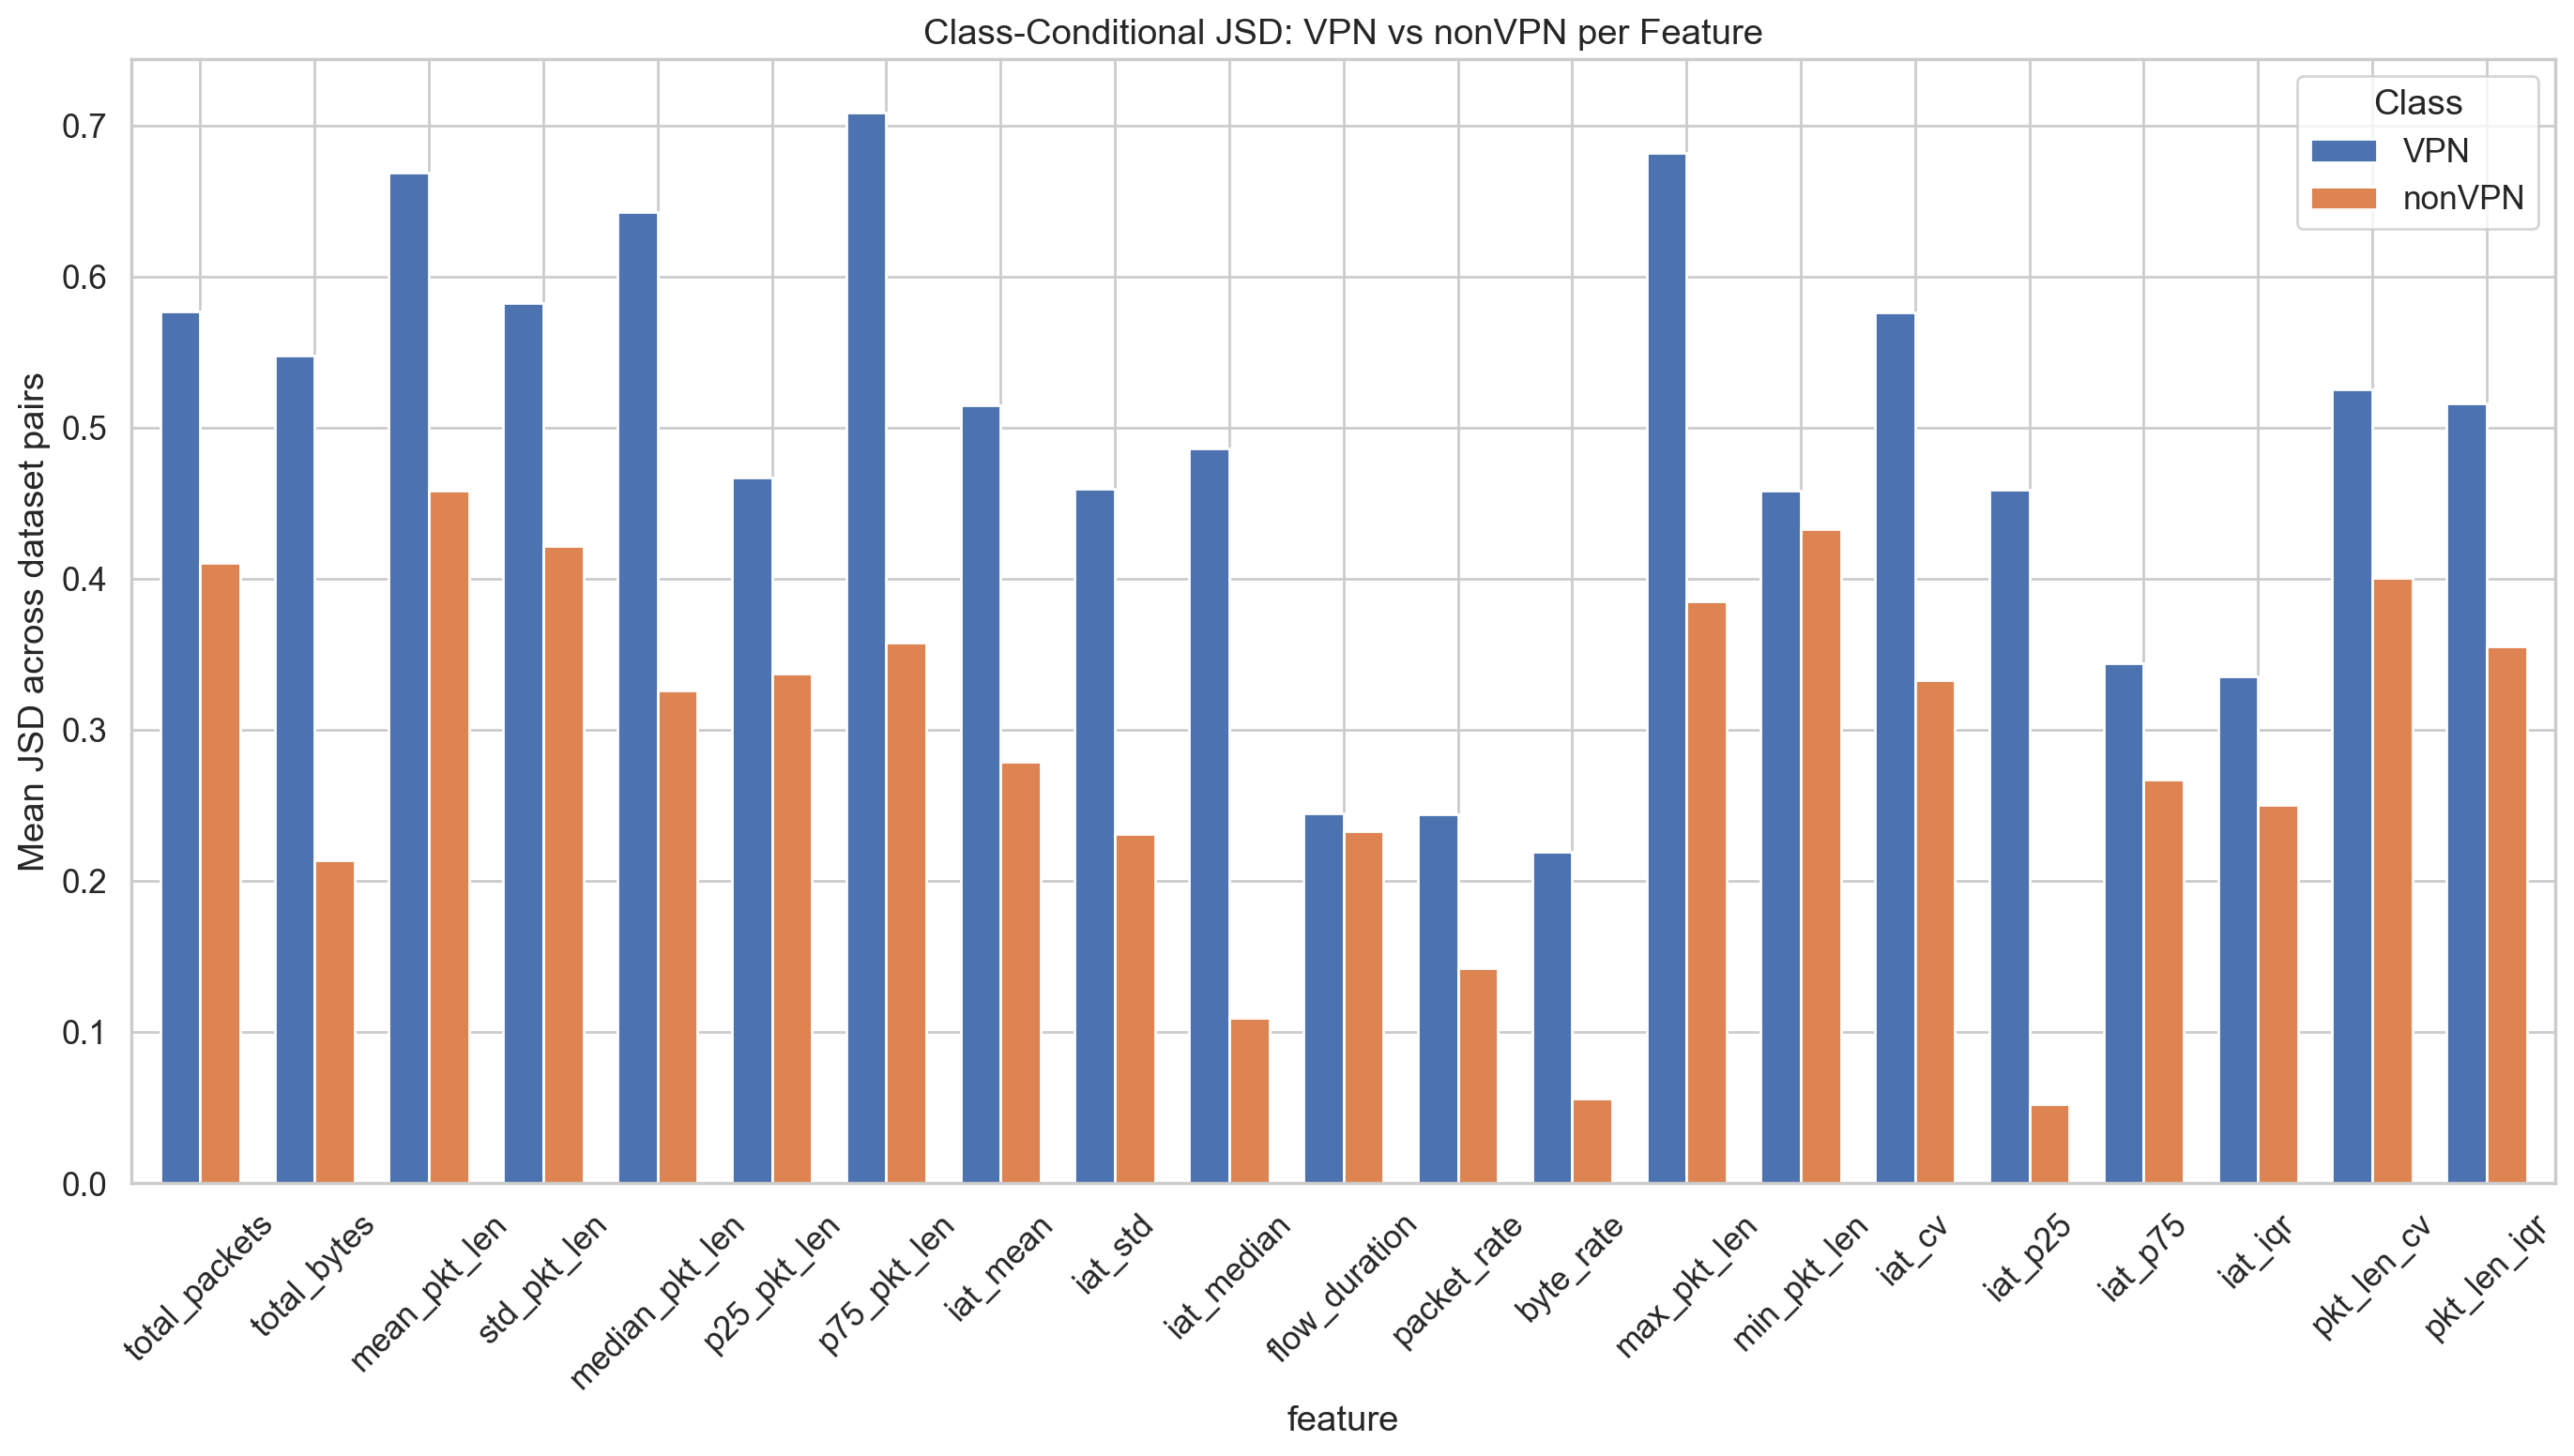


▶ class_conditional_jsd_heatmap.png


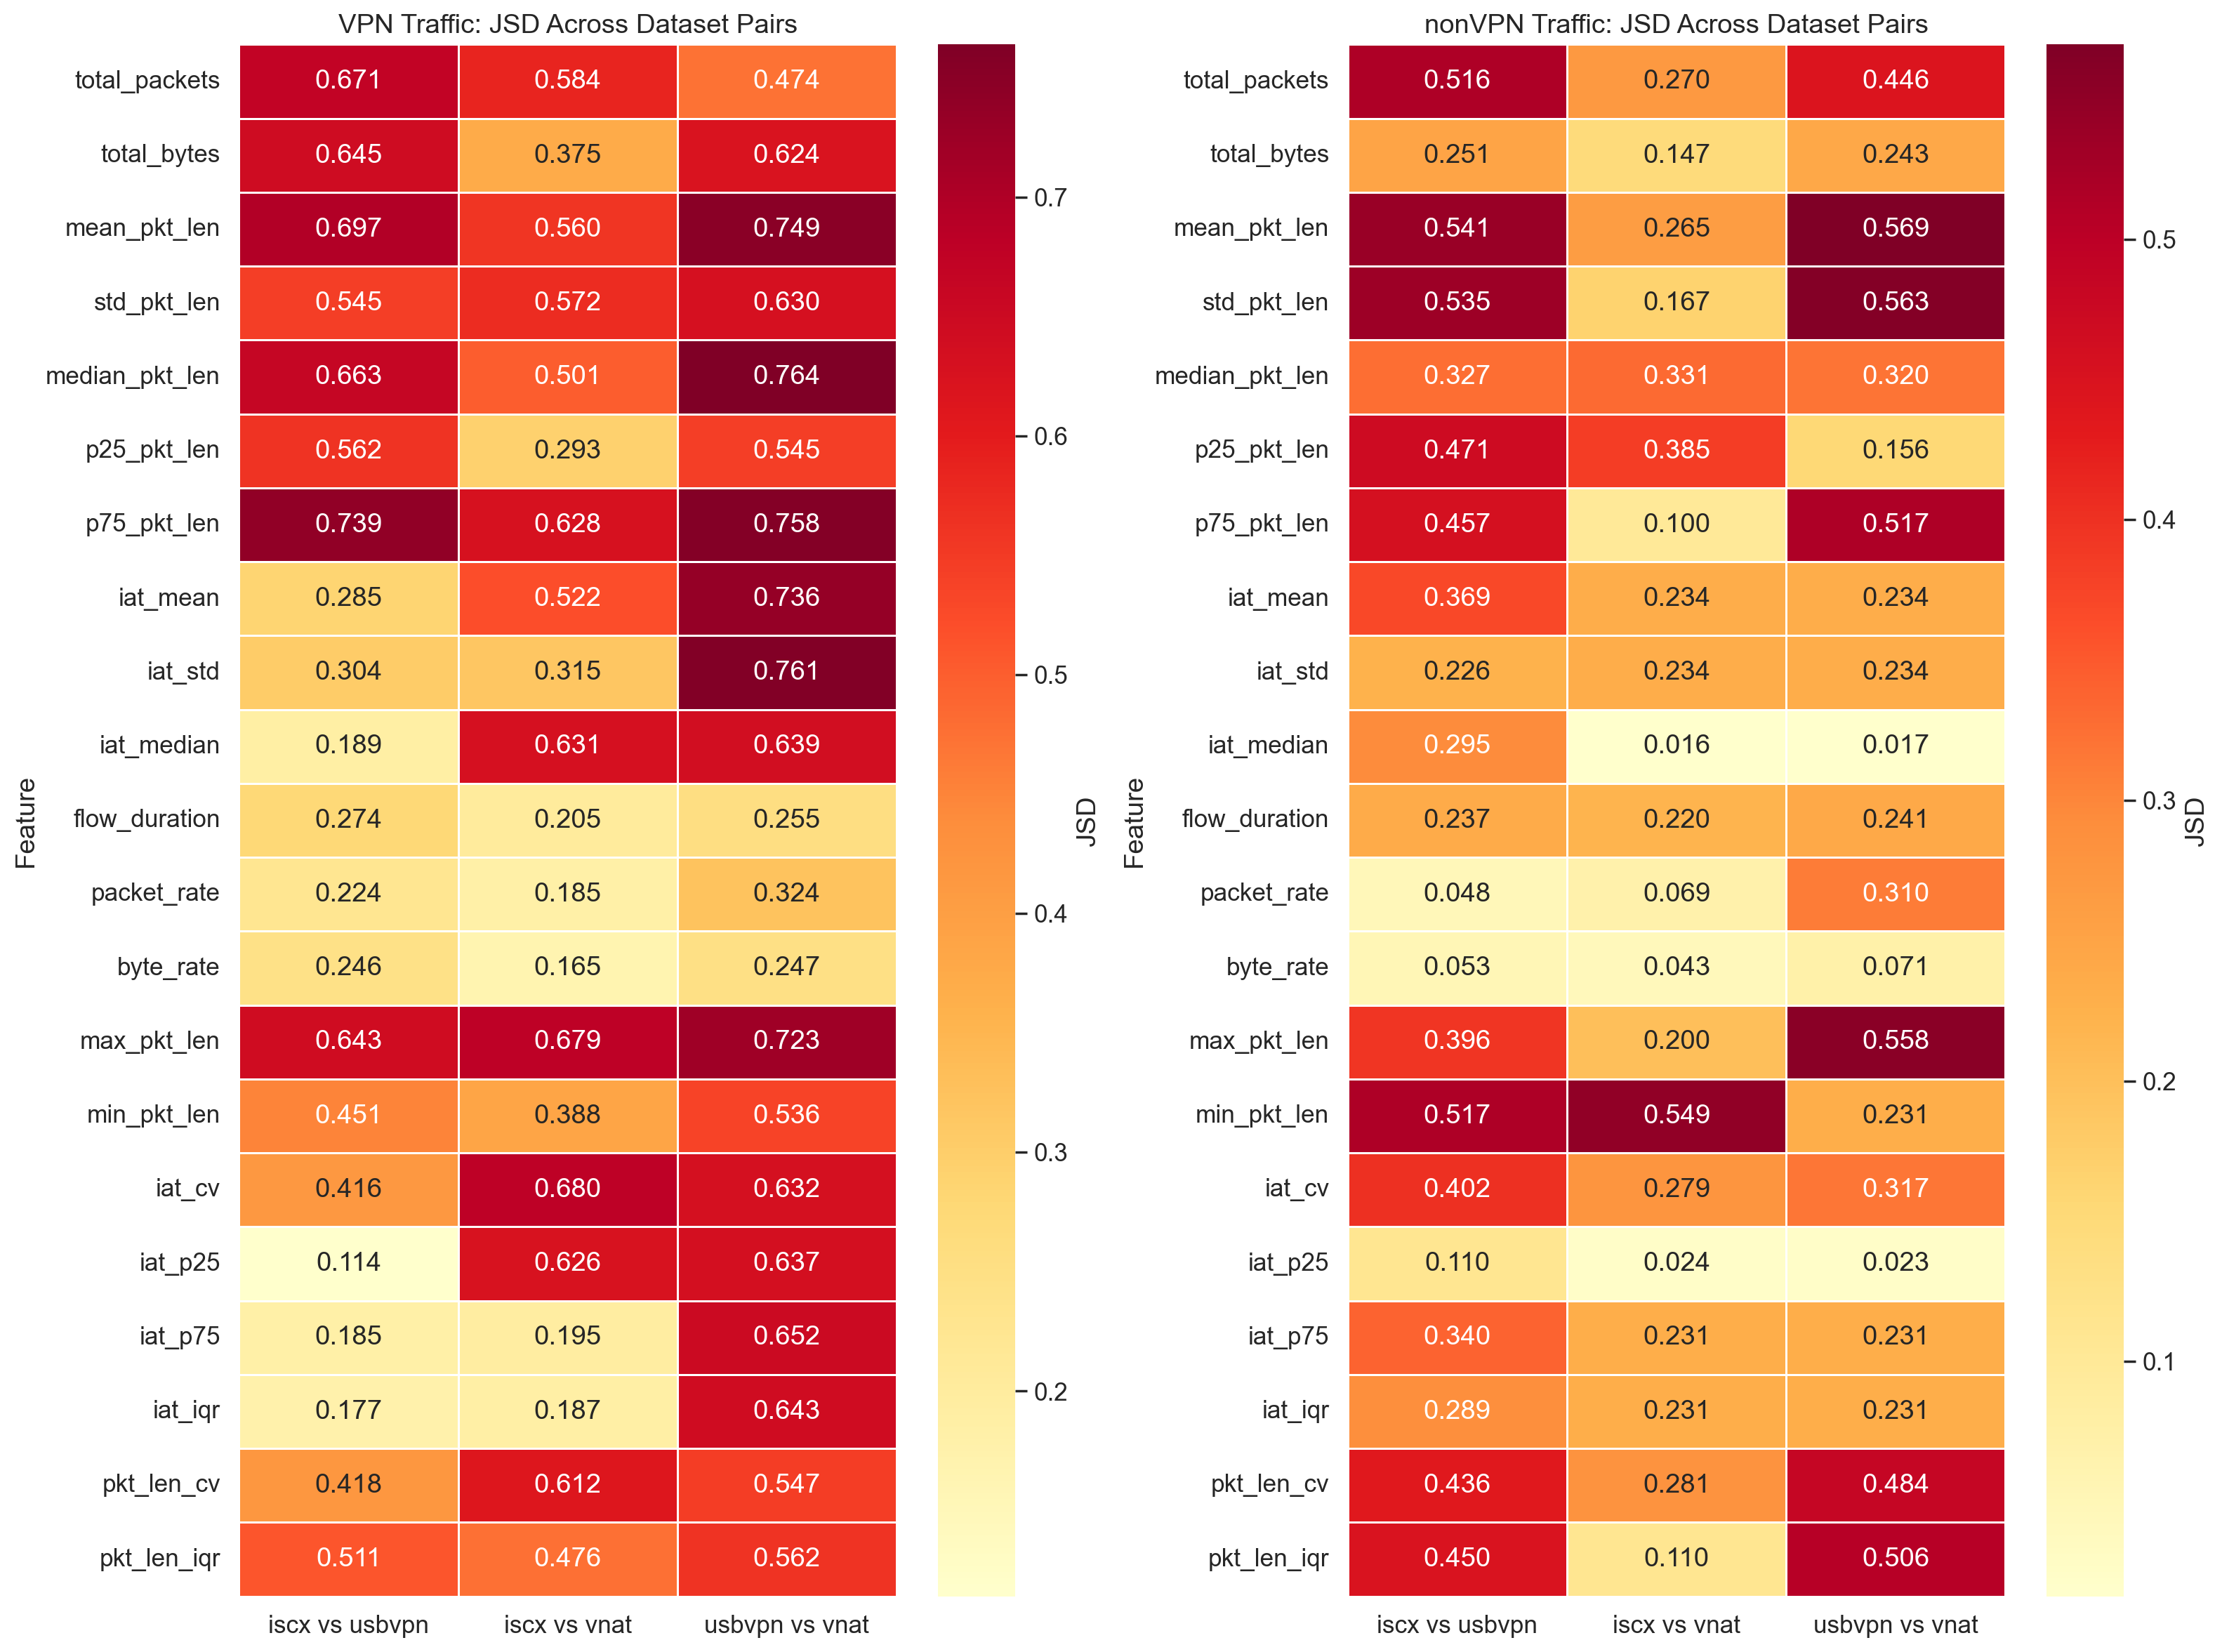


▶ effect_size_heatmap.png


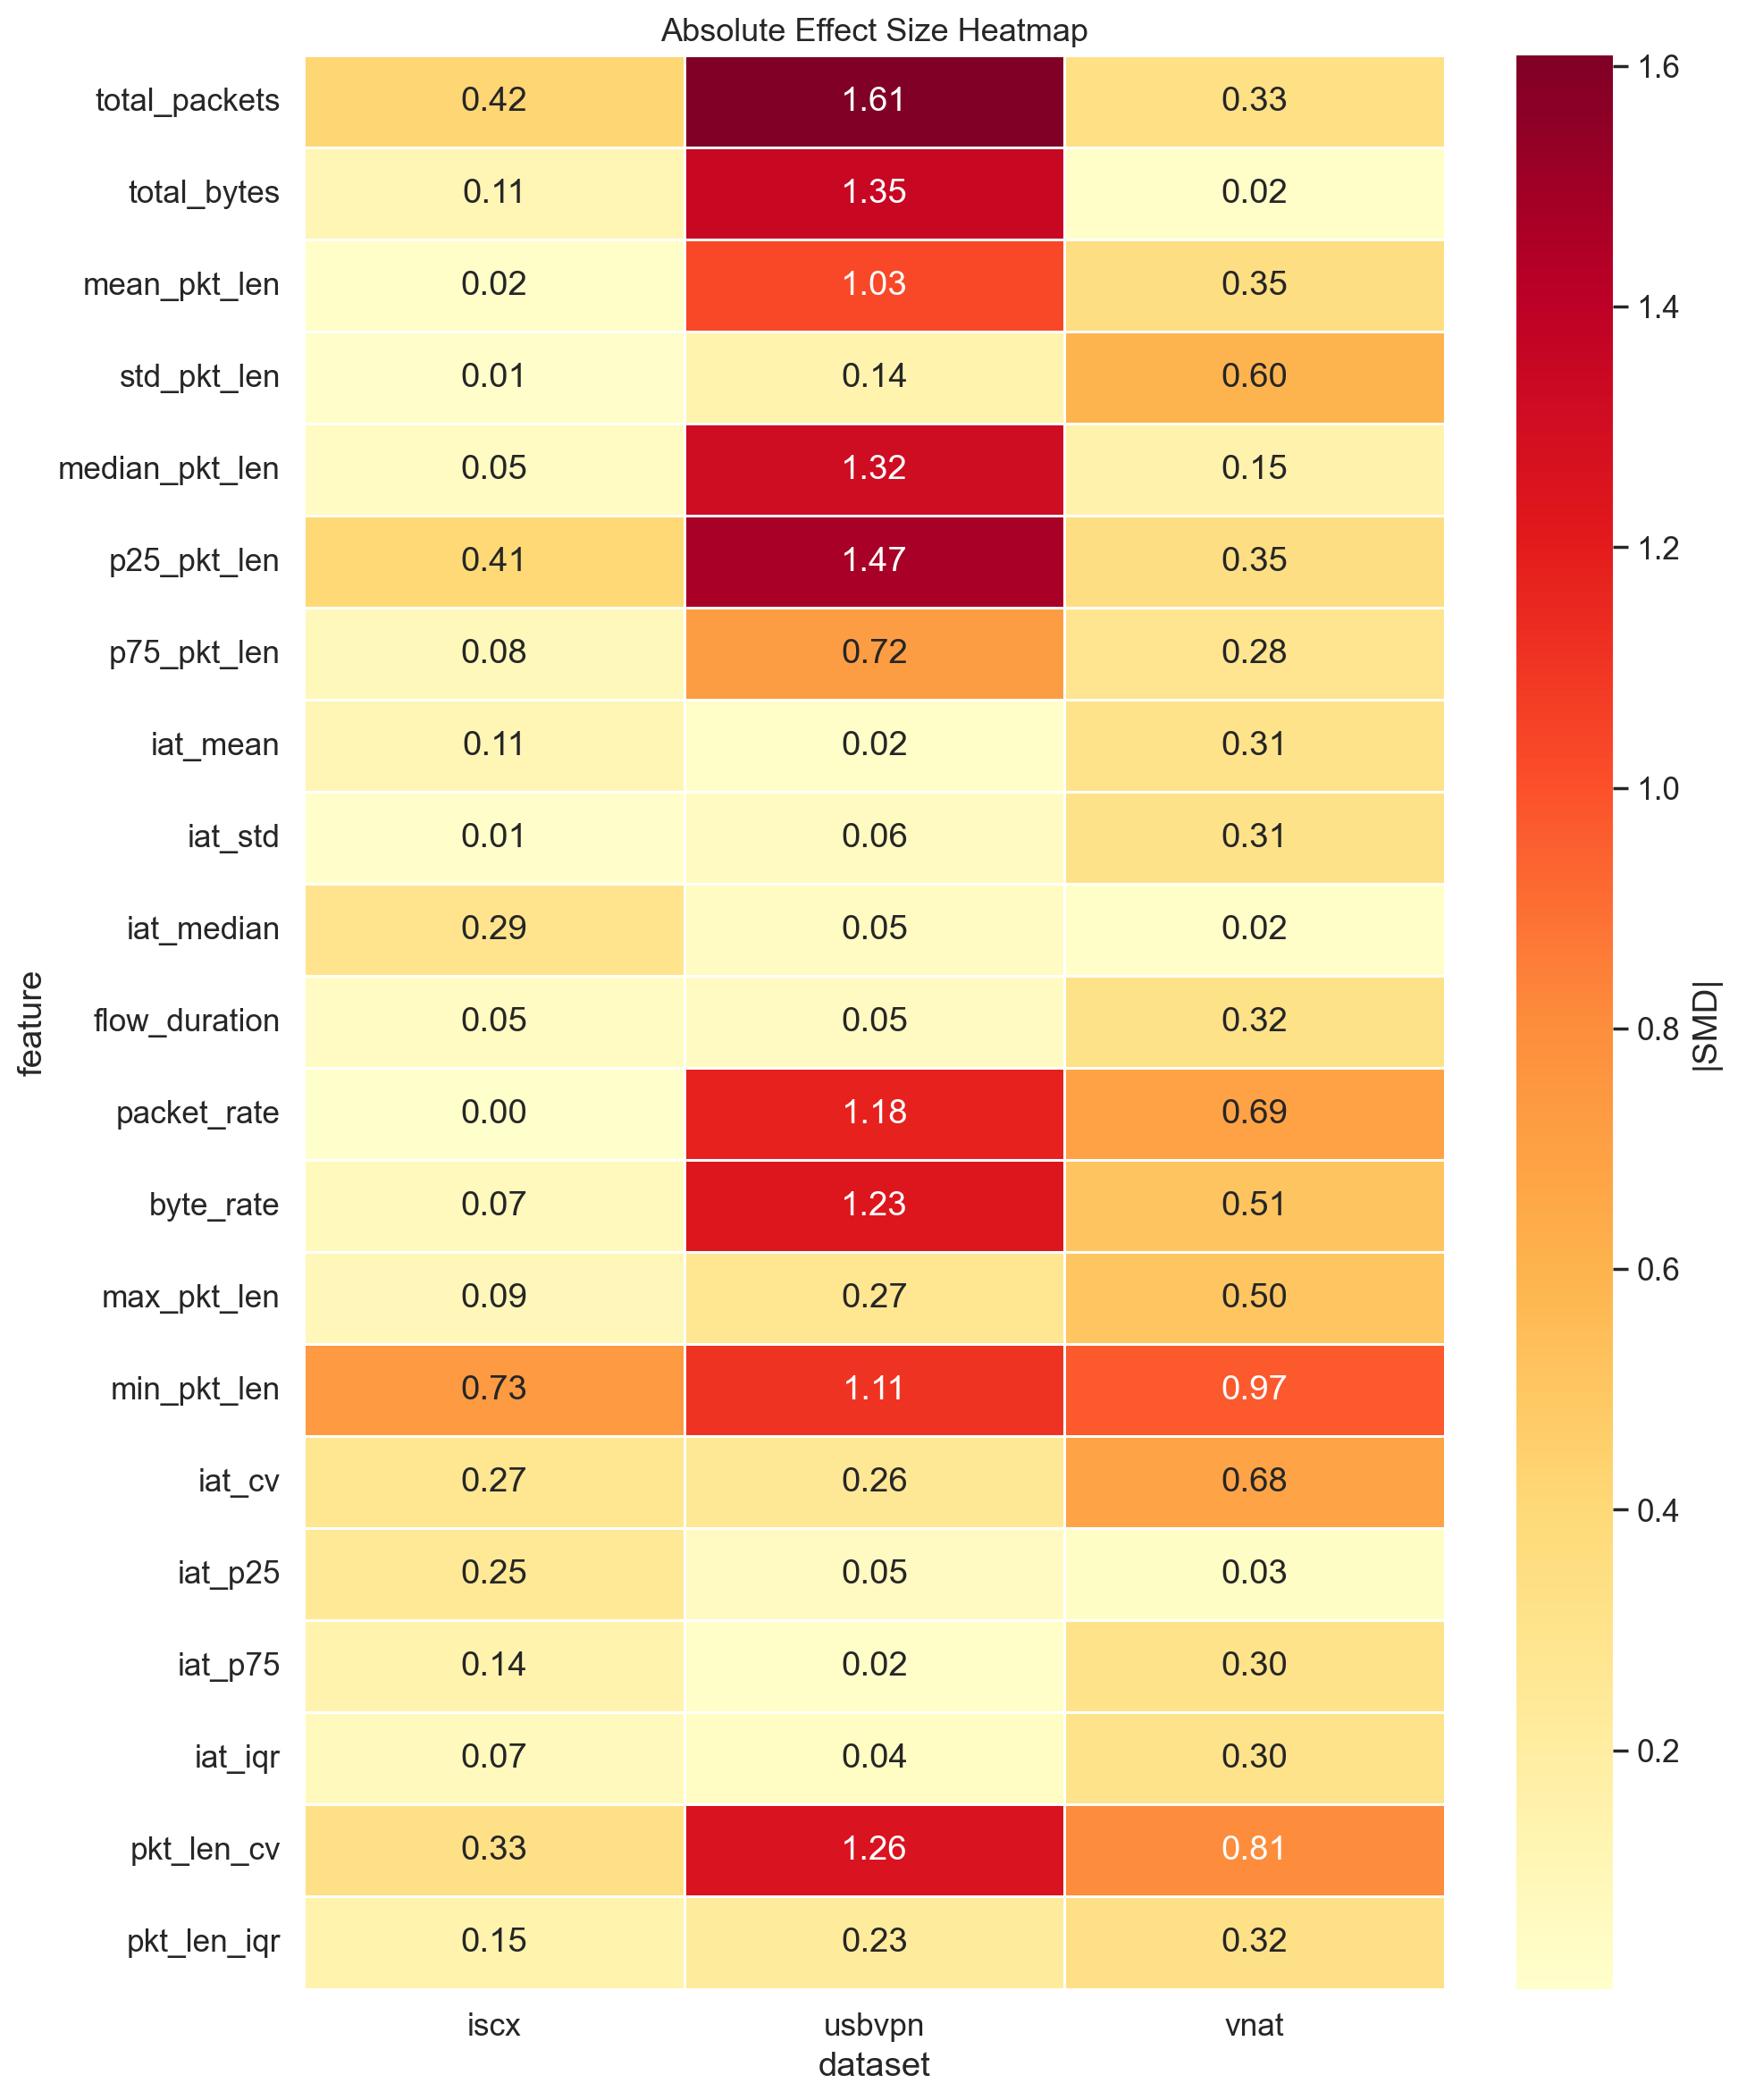


▶ reversal_strength_ranking.png


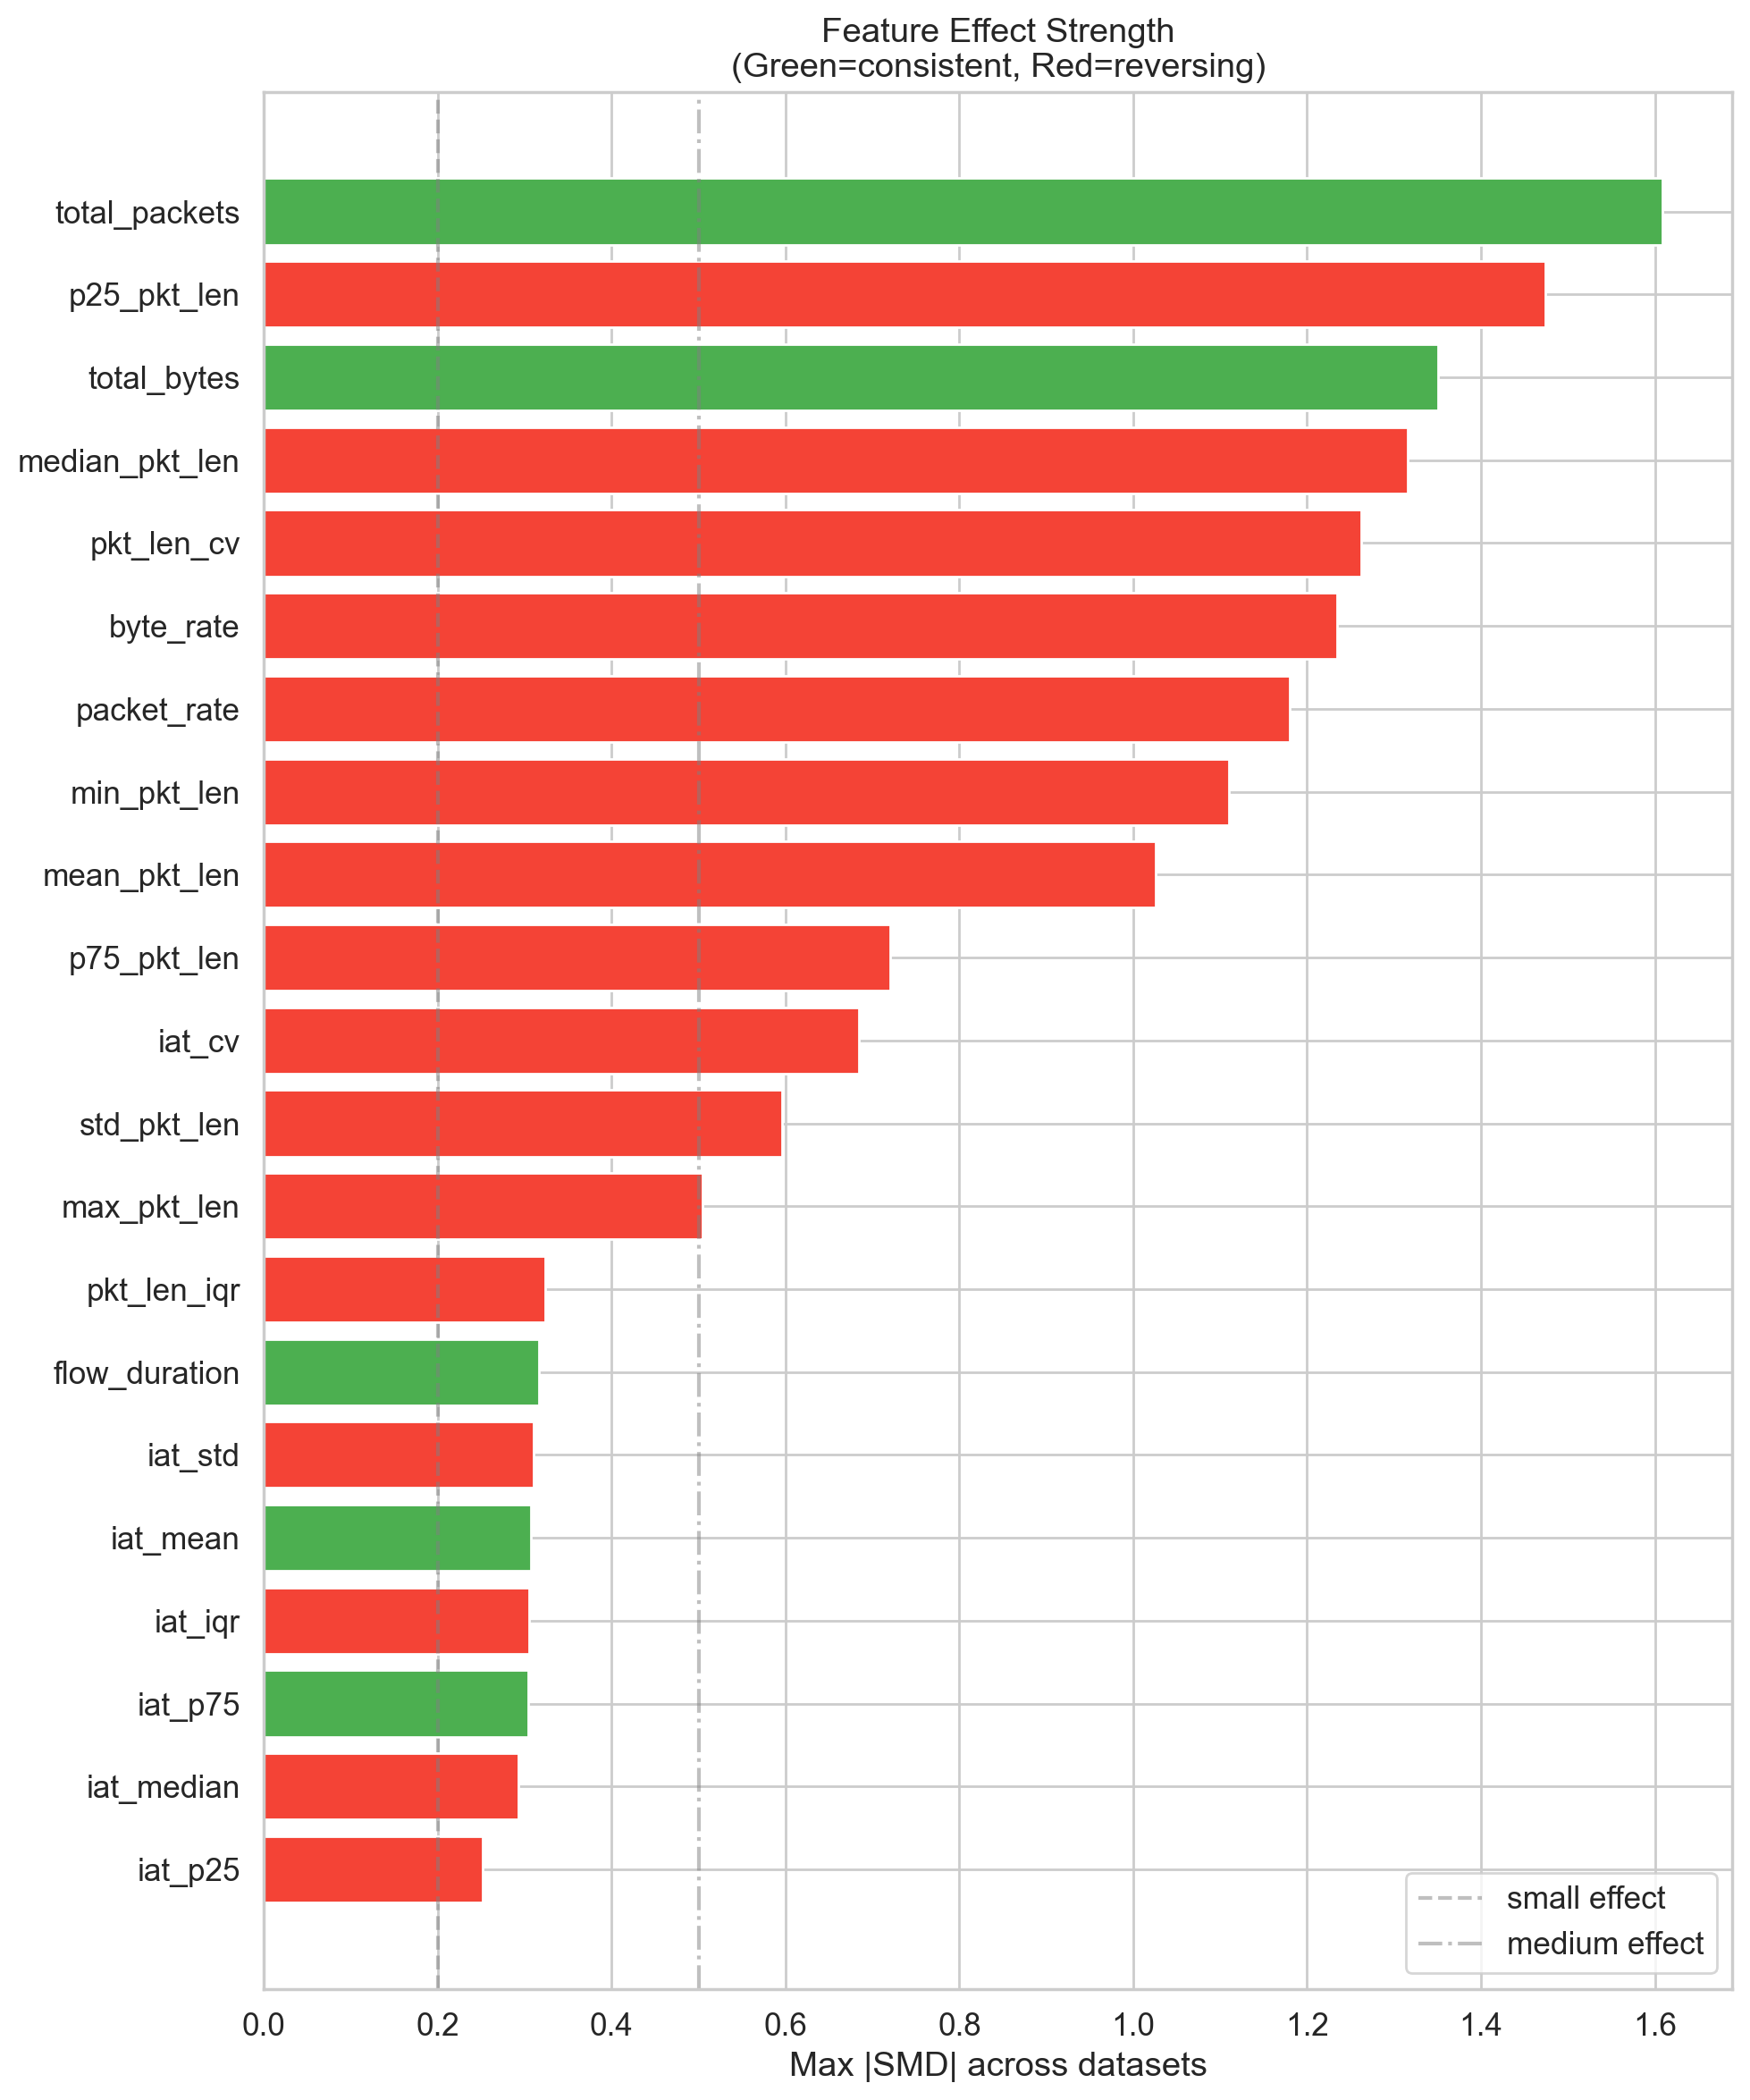


▶ sign_reversal_heatmap.png


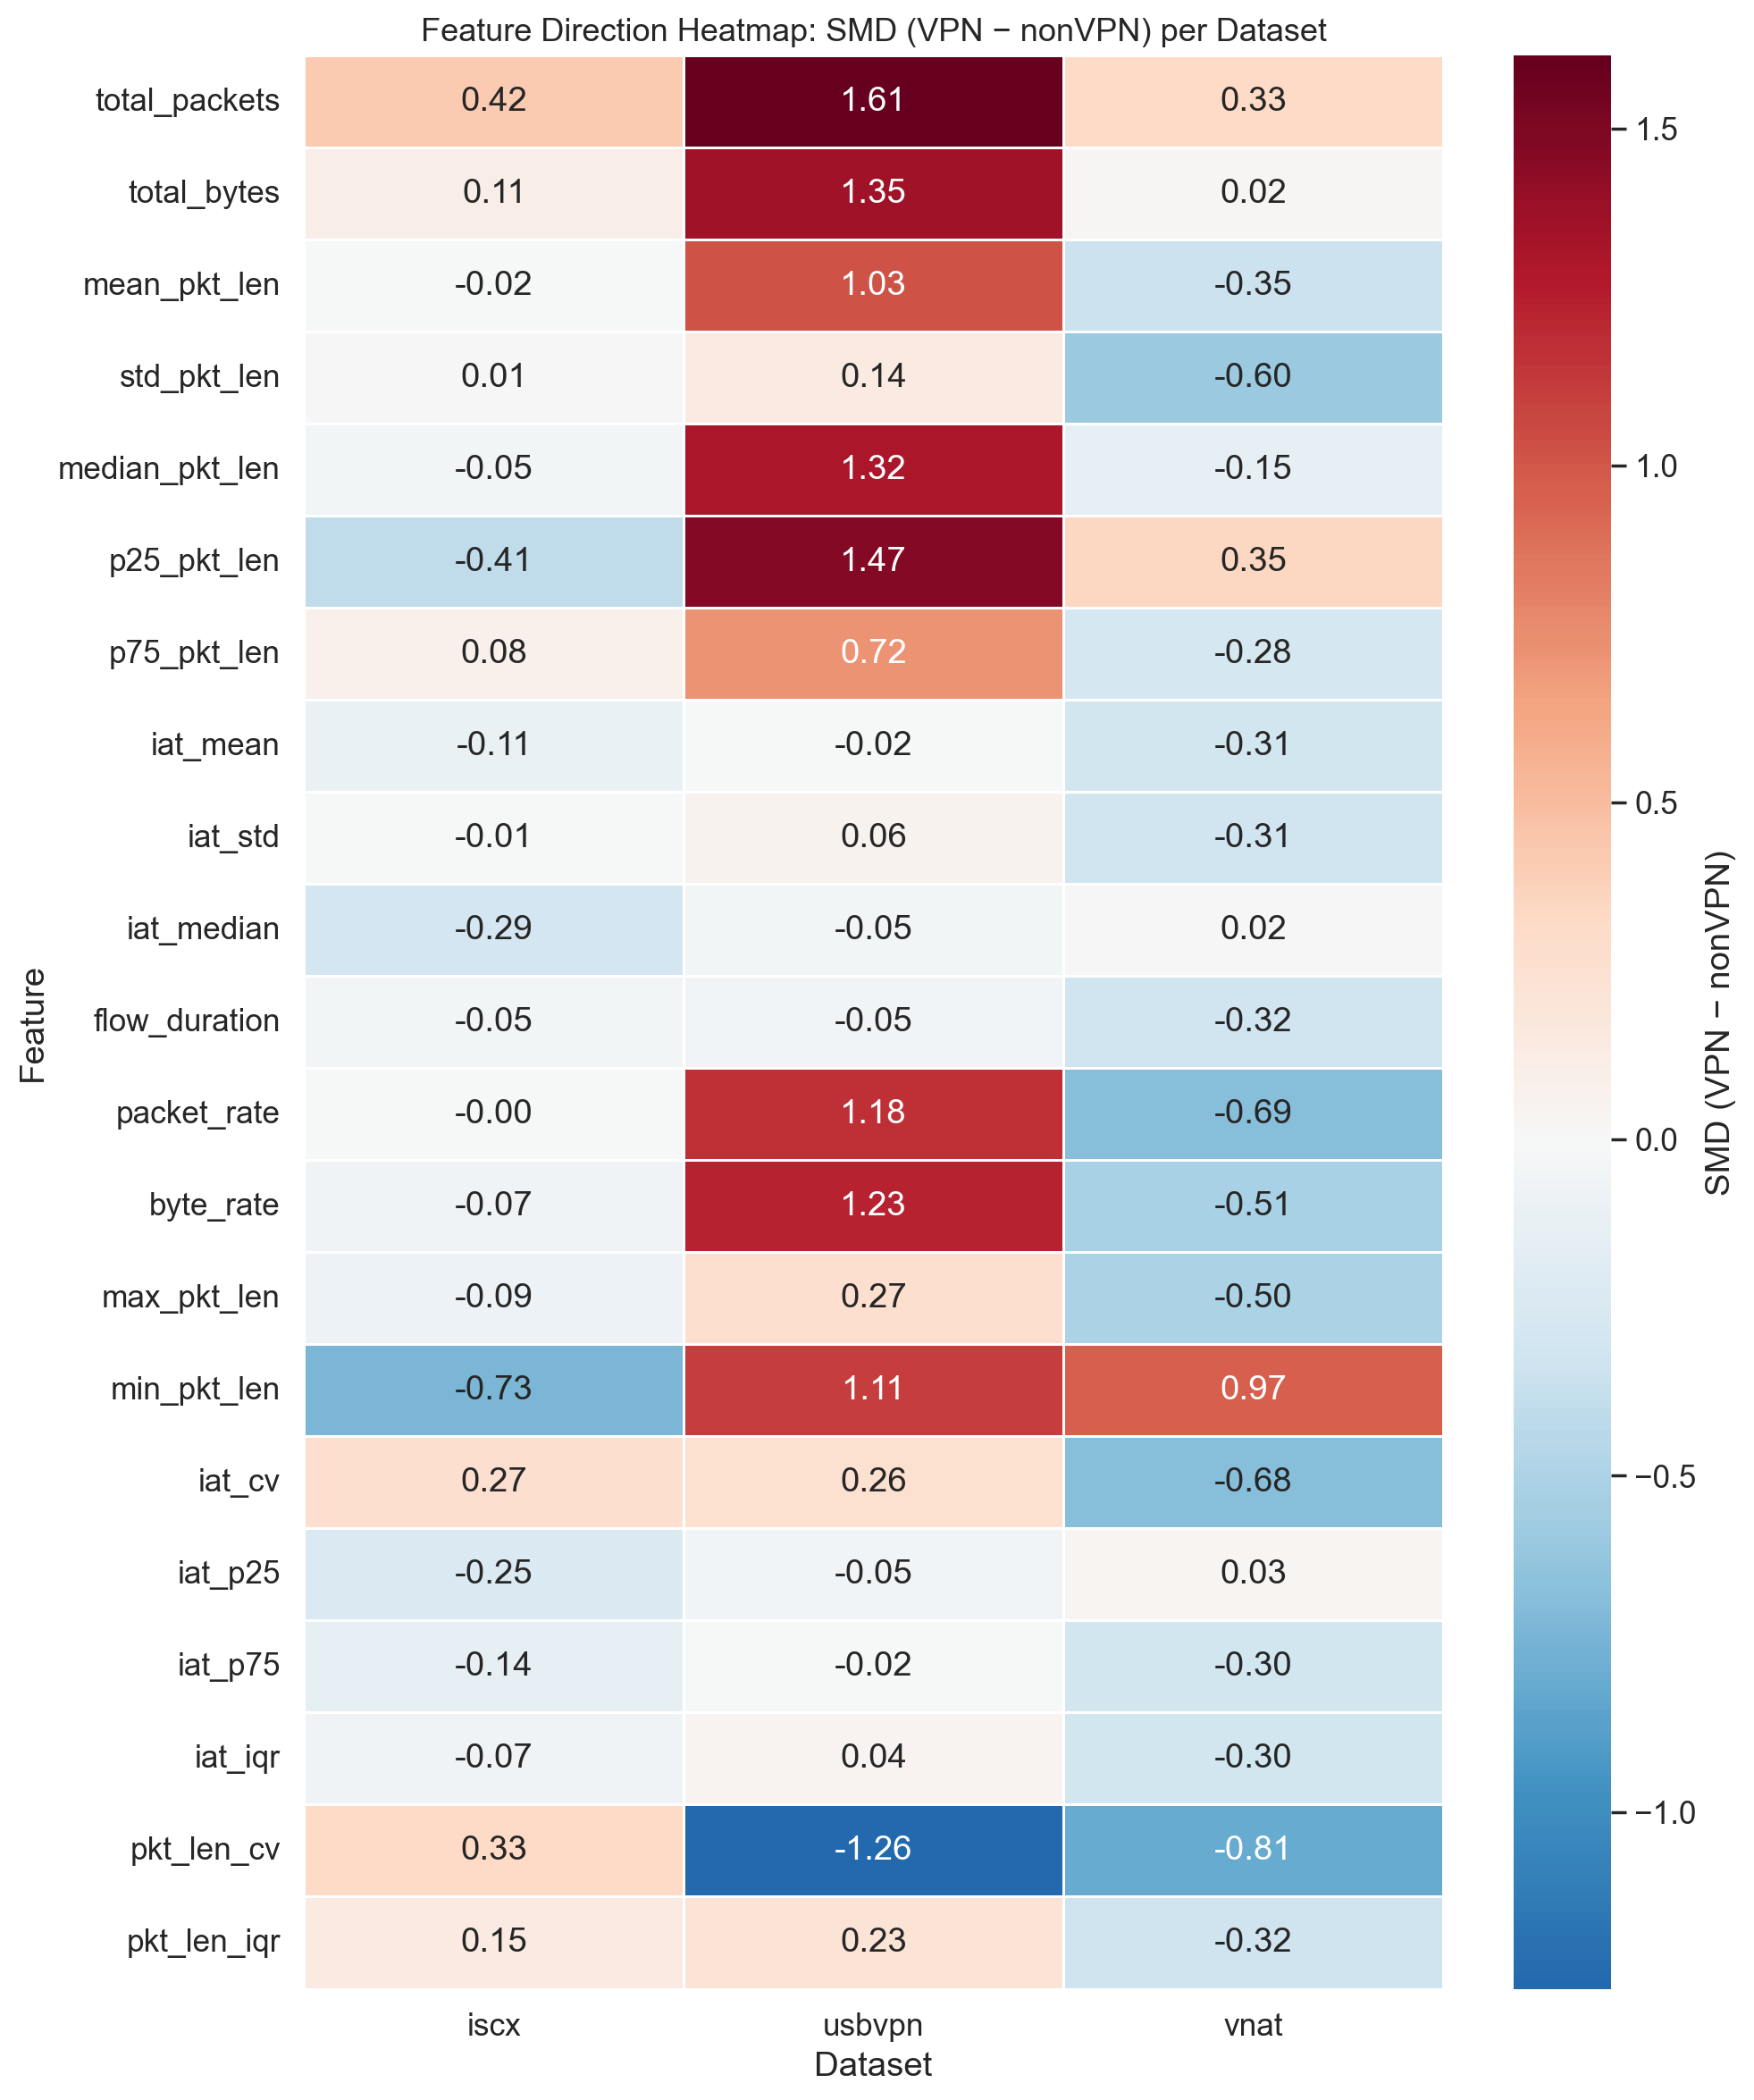


▶ single_feature_auc_comparison.png


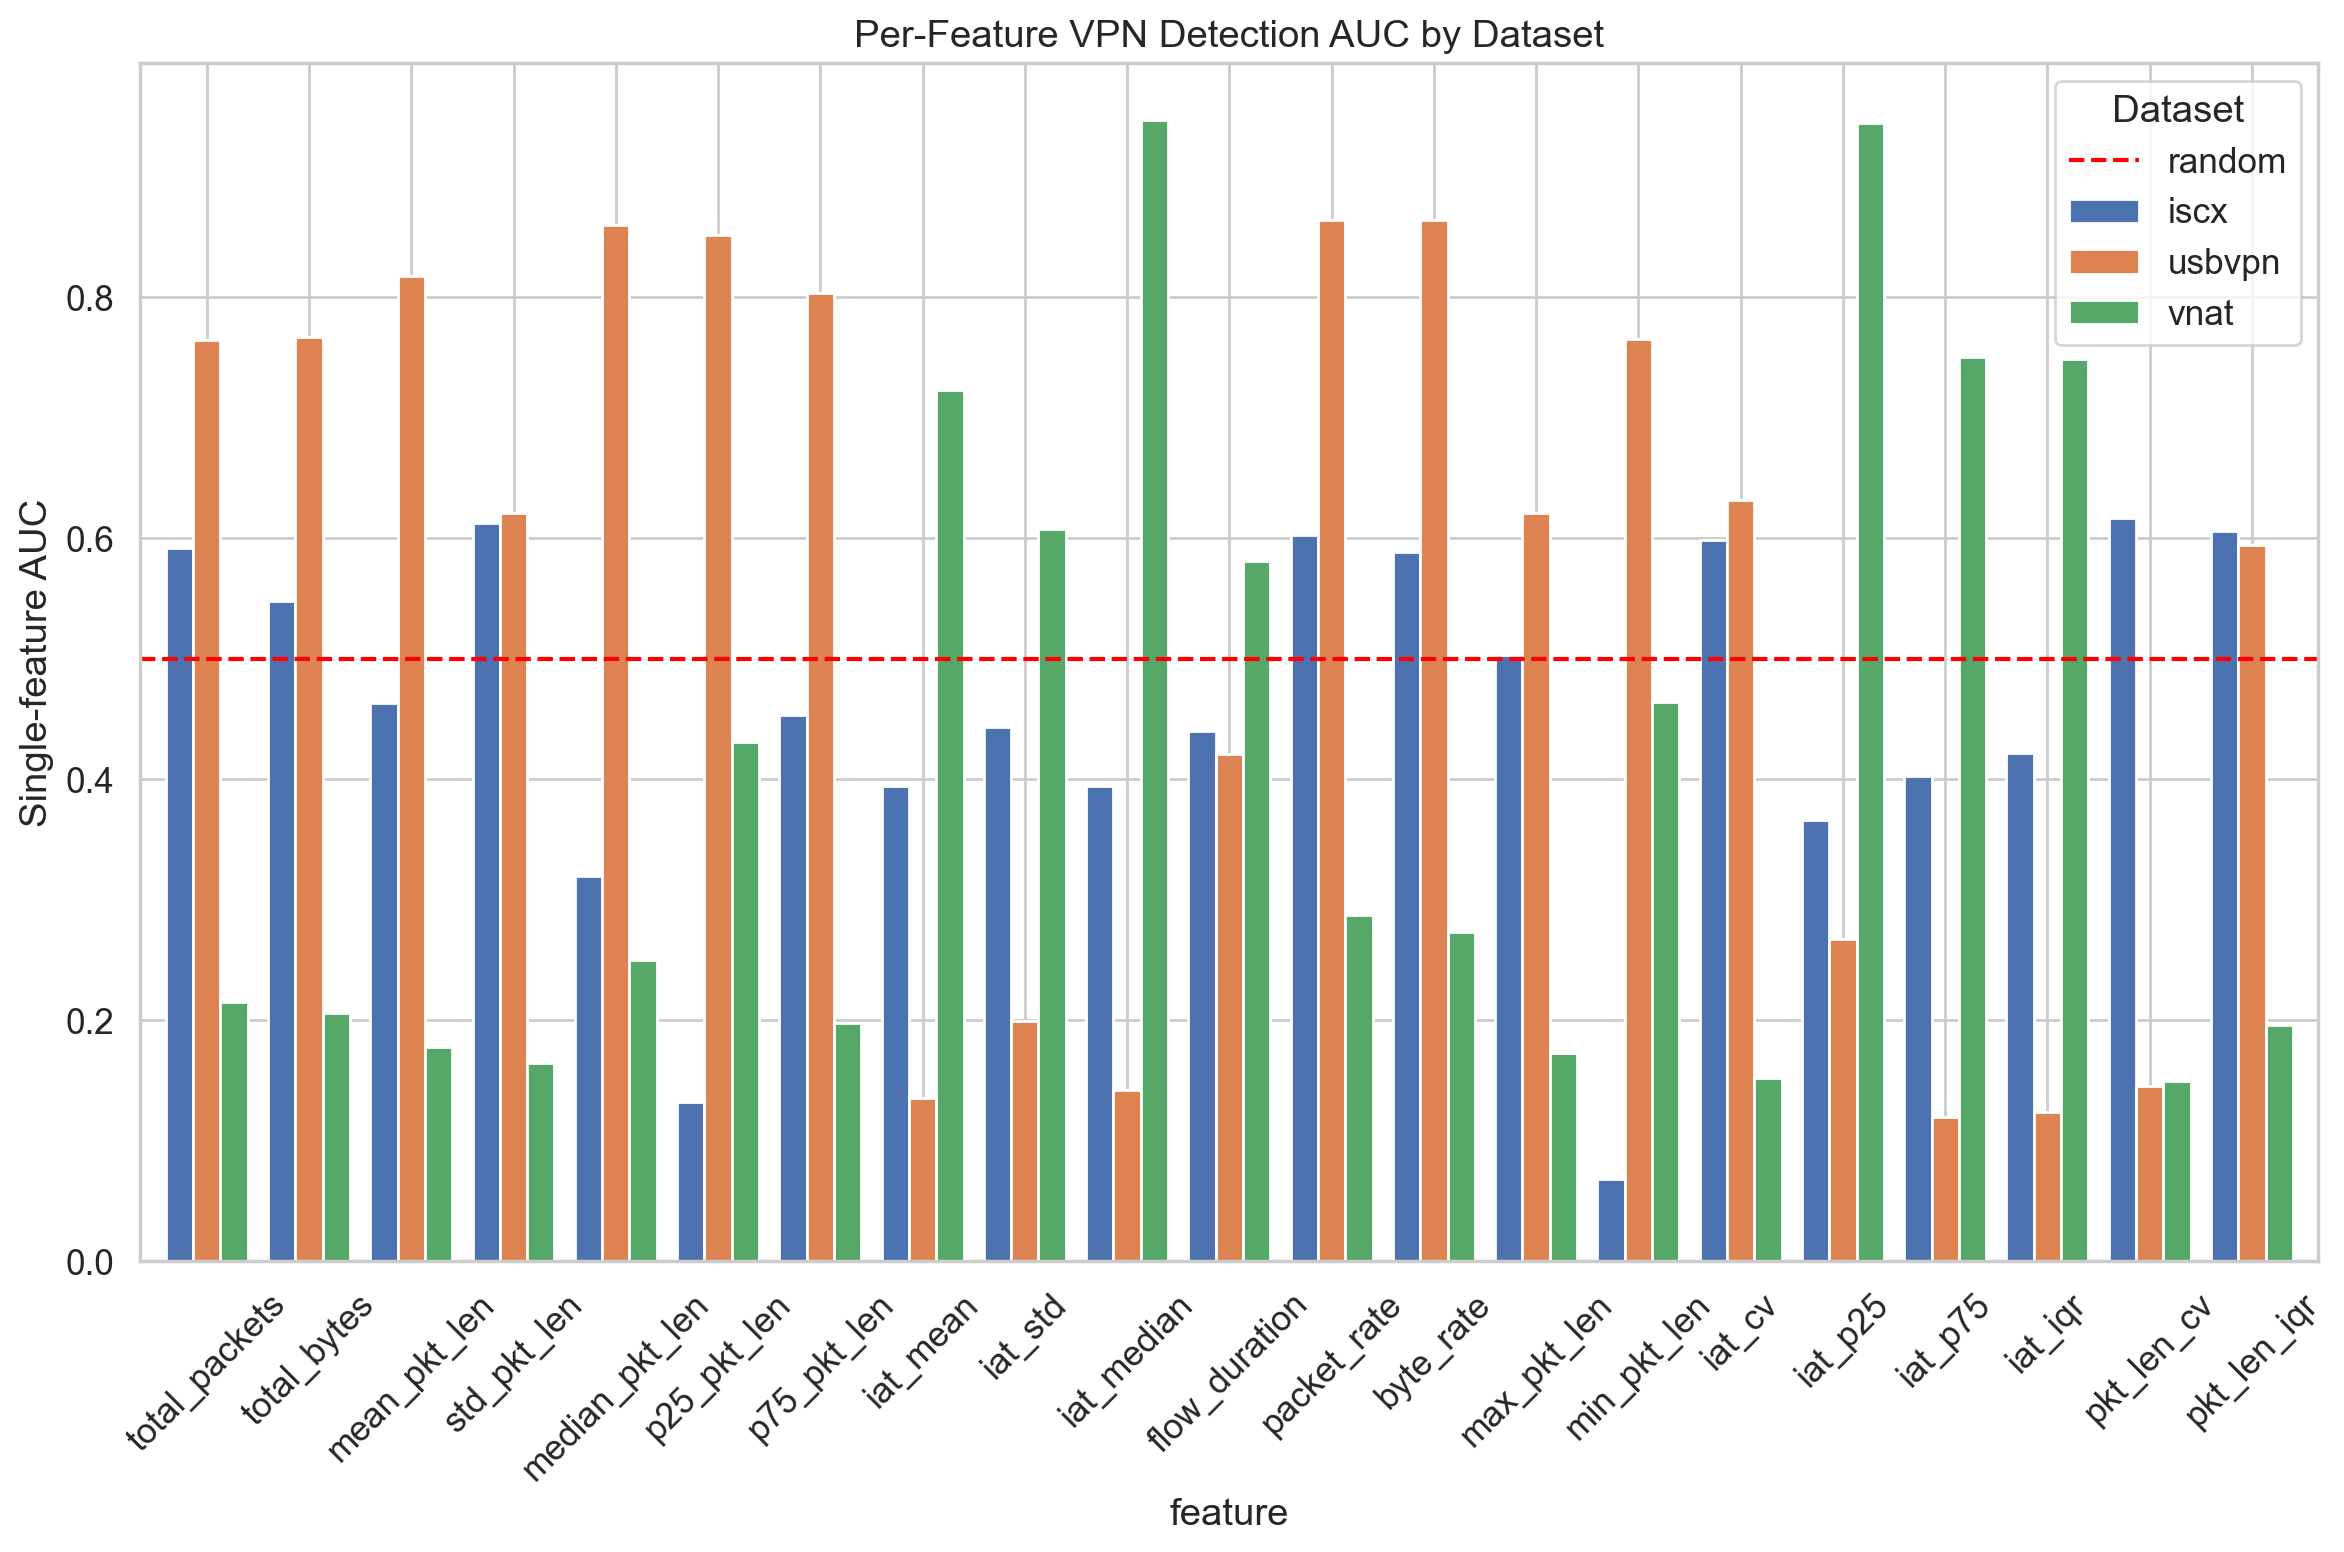



TABLE 1 — Sign Reversal Matrix (per-feature reversal status)


,feature,iscx_sign,usbvpn_sign,vnat_sign,reversal_by_smd,reversal_by_auc,reversal_by_delta,triple_consensus_reversal,reversal_category
0,total_packets,1.0,1.0,1.0,False,True,True,False,PARTIAL_REVERSAL
1,total_bytes,1.0,1.0,1.0,False,True,True,False,PARTIAL_REVERSAL
2,mean_pkt_len,-1.0,1.0,-1.0,True,True,True,True,CONSENSUS_REVERSAL
3,std_pkt_len,1.0,1.0,-1.0,True,True,True,True,CONSENSUS_REVERSAL
4,median_pkt_len,-1.0,1.0,-1.0,True,True,True,True,CONSENSUS_REVERSAL
5,p25_pkt_len,-1.0,1.0,1.0,True,True,True,True,CONSENSUS_REVERSAL
6,p75_pkt_len,1.0,1.0,-1.0,True,True,True,True,CONSENSUS_REVERSAL
7,iat_mean,-1.0,-1.0,-1.0,False,True,True,False,PARTIAL_REVERSAL
8,iat_std,-1.0,1.0,-1.0,True,True,True,True,CONSENSUS_REVERSAL
9,iat_median,-1.0,-1.0,1.0,True,True,True,True,CONSENSUS_REVERSAL



TABLE 2 — Standardized Mean Difference (VPN − nonVPN) per Dataset


dataset,iscx,usbvpn,vnat
feature,,,
total_packets,0.421,1.609,0.330
total_bytes,0.113,1.351,0.018
mean_pkt_len,-0.016,1.025,-0.351
std_pkt_len,0.010,0.141,-0.596
median_pkt_len,-0.047,1.316,-0.151
p25_pkt_len,-0.406,1.474,0.350
p75_pkt_len,0.082,0.720,-0.278
iat_mean,-0.106,-0.017,-0.307
iat_std,-0.011,0.056,-0.310



TABLE 3 — Single-Feature AUC per Dataset


...


TABLE 6 — Class-Conditional JSD Summary


,class,mean,std,median
0,ALL,0.274811,0.151058,0.250071
1,VPN,0.488465,0.194225,0.545388
2,nonVPN,0.288155,0.161004,0.264709



TABLE 7 — Consensus Reversal Features


,feature,reversal_by_smd,reversal_by_auc,reversal_by_delta,triple_consensus_reversal,any_definition_reversal,n_definitions_agree,reversal_category,max_abs_effect
0,total_packets,False,True,True,False,True,2,PARTIAL_REVERSAL,1.608532
1,total_bytes,False,True,True,False,True,2,PARTIAL_REVERSAL,1.350691
2,mean_pkt_len,True,True,True,True,True,3,CONSENSUS_REVERSAL,1.025274
3,std_pkt_len,True,True,True,True,True,3,CONSENSUS_REVERSAL,0.595939
4,median_pkt_len,True,True,True,True,True,3,CONSENSUS_REVERSAL,1.315953
5,p25_pkt_len,True,True,True,True,True,3,CONSENSUS_REVERSAL,1.473741
6,p75_pkt_len,True,True,True,True,True,3,CONSENSUS_REVERSAL,0.720430
7,iat_mean,False,True,True,False,True,2,PARTIAL_REVERSAL,0.307348
8,iat_std,True,True,True,True,True,3,CONSENSUS_REVERSAL,0.310245
9,iat_median,True,True,True,True,True,3,CONSENSUS_REVERSAL,0.292924



✅ All figures and tables displayed.


In [8]:
from IPython.display import display, Image as IPImage, Markdown
import glob as _glob

# ── 1. Display all generated PNG figures ──────────────────────────────────────
png_files = sorted(OUT.glob("*.png"))
print(f"=== Generated Figures ({len(png_files)}) ===\n")
for png in png_files:
    print(f"▶ {png.name}")
    display(IPImage(filename=str(png), width=900))
    print()

# ── 2. Key Table: Sign Reversal Matrix ────────────────────────────────────────
print("\n" + "="*70)
print("TABLE 1 — Sign Reversal Matrix (per-feature reversal status)")
print("="*70)
display_cols_t1 = (["feature"]
                   + [f"{ds}_sign" for ds in DATASETS]
                   + ["reversal_by_smd", "reversal_by_auc", "reversal_by_delta",
                      "triple_consensus_reversal", "reversal_category"])
display(matrix_df[display_cols_t1])

# ── 3. Key Table: SMD pivot (feature × dataset) ──────────────────────────────
print("\n" + "="*70)
print("TABLE 2 — Standardized Mean Difference (VPN − nonVPN) per Dataset")
print("="*70)
display(smd_pivot.reindex(FEAT_COLS).round(3))

# ── 4. Key Table: Single-feature AUC pivot ────────────────────────────────────
print("\n" + "="*70)
print("TABLE 3 — Single-Feature AUC per Dataset")
print("="*70)
display(auc_pivot.reindex(FEAT_COLS).round(4))

# ── 5. Key Table: Cliff's delta pivot ─────────────────────────────────────────
print("\n" + "="*70)
print("TABLE 4 — Cliff's Delta per Dataset")
print("="*70)
display(delta_pivot.reindex(FEAT_COLS).round(4))

# ── 6. Key Table: LODO reversal analysis ──────────────────────────────────────
print("\n" + "="*70)
print("TABLE 5 — LODO Top-10 Feature Reversal Analysis")
print("="*70)
display(lodo_rev_df)

# ── 7. Key Table: Class-Conditional JSD summary ──────────────────────────────
print("\n" + "="*70)
print("TABLE 6 — Class-Conditional JSD Summary")
print("="*70)
display(jsd_summary)

# ── 8. Consensus reversal features ────────────────────────────────────────────
print("\n" + "="*70)
print("TABLE 7 — Consensus Reversal Features")
print("="*70)
display(consensus_features)

print("\n✅ All figures and tables displayed.")

